In [ ]:
import pandas as pd
import polars as pl
import duckdb
import matplotlib.pyplot as plt

print("halo")

In [ ]:
df = pd.read_csv("AirBnb_data_case-study/Best_Property/listings_clean.csv")

# Buat tabel permanen dari DataFrame dengan alias "sales"
duckdb.sql("CREATE TABLE listing AS SELECT * FROM df")


In [10]:
duckdb.sql("""
    SELECT AVG(total_revenue_all) AS mean_revenue
    FROM listing
    WHERE review_scores_rating >= 80
""")


┌────────────────────┐
│    mean_revenue    │
│       double       │
├────────────────────┤
│ 48041.657232704405 │
└────────────────────┘

In [11]:
duckdb.sql("""
    SELECT
        AVG(CASE WHEN review_scores_rating >= 80 THEN total_revenue_all END) AS mean_high_rating,
        AVG(CASE WHEN review_scores_rating < 80 THEN total_revenue_all END) AS mean_low_rating
    FROM listing
""")


┌────────────────────┬───────────────────┐
│  mean_high_rating  │  mean_low_rating  │
│       double       │      double       │
├────────────────────┼───────────────────┤
│ 48041.657232704405 │ 33236.92168674699 │
└────────────────────┴───────────────────┘

In [12]:
duckdb.sql("""
    SELECT 
        CASE WHEN review_scores_rating >= 80 THEN 'High Rating (>=80)'
             ELSE 'Low Rating (<80)' END AS rating_group,
        AVG(total_revenue_all) AS mean_revenue
    FROM listing
    GROUP BY rating_group
""")


┌────────────────────┬────────────────────┐
│    rating_group    │    mean_revenue    │
│      varchar       │       double       │
├────────────────────┼────────────────────┤
│ High Rating (>=80) │ 48041.657232704405 │
│ Low Rating (<80)   │  59889.38912579957 │
└────────────────────┴────────────────────┘

In [13]:
duckdb.sql("""
    SELECT 
        CASE WHEN review_scores_rating >= 80 THEN 'High Rating (>=80)'
             ELSE 'Low Rating (<80)' END AS rating_group,
        COUNT(*) AS total_listings,
        AVG(total_revenue_all) AS mean_revenue
    FROM listing
    GROUP BY rating_group
""")


┌────────────────────┬────────────────┬────────────────────┐
│    rating_group    │ total_listings │    mean_revenue    │
│      varchar       │     int64      │       double       │
├────────────────────┼────────────────┼────────────────────┤
│ Low Rating (<80)   │            938 │  59889.38912579957 │
│ High Rating (>=80) │           2544 │ 48041.657232704405 │
└────────────────────┴────────────────┴────────────────────┘

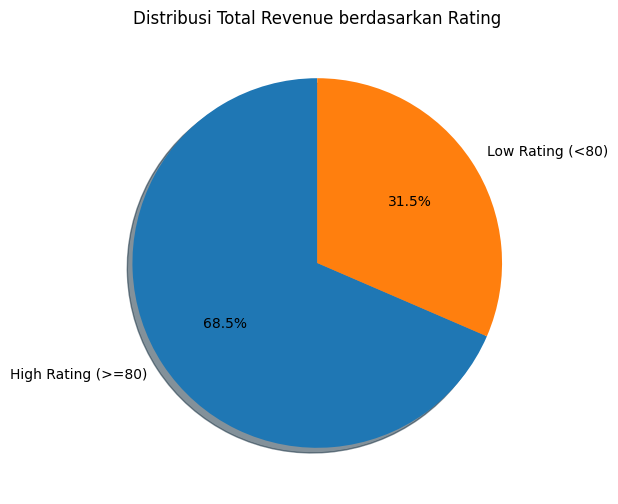

In [14]:
# Query untuk ambil total revenue per kategori rating
df_pie = duckdb.sql("""
    SELECT 
        CASE WHEN review_scores_rating >= 80 THEN 'High Rating (>=80)'
             ELSE 'Low Rating (<80)' END AS rating_group,
        SUM(total_revenue_all) AS total_revenue
    FROM listing
    GROUP BY rating_group
""").df()

# Plot Pie Chart
plt.figure(figsize=(6,6))
plt.pie(
    df_pie["total_revenue"], 
    labels=df_pie["rating_group"], 
    autopct='%1.1f%%', 
    startangle=90,
    shadow=True
)
plt.title("Distribusi Total Revenue berdasarkan Rating")
plt.show()


# RATING DOESNT DO ANYTHING WITH REVENUE

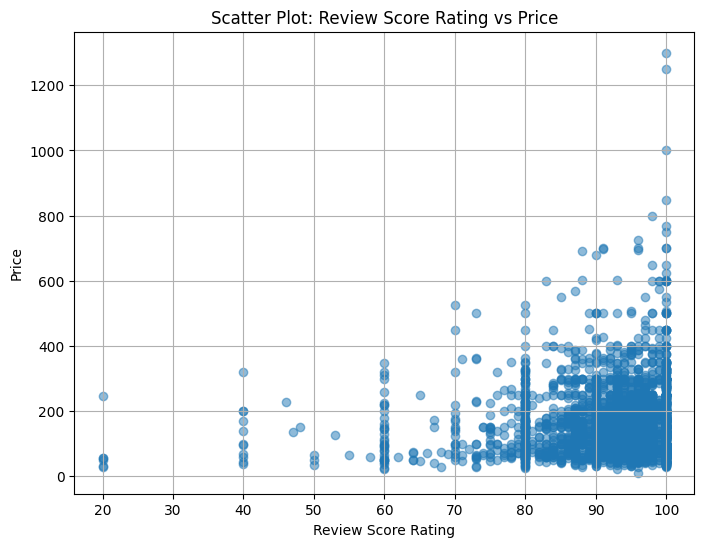

In [15]:
# Ambil data rating dan price
df_scatter = duckdb.sql("""
    SELECT review_scores_rating, price
    FROM listing
    WHERE price IS NOT NULL 
      AND review_scores_rating IS NOT NULL
""").df()

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df_scatter["review_scores_rating"], df_scatter["price"], alpha=0.5)
plt.xlabel("Review Score Rating")
plt.ylabel("Price")
plt.title("Scatter Plot: Review Score Rating vs Price")
plt.grid(True)
plt.show()

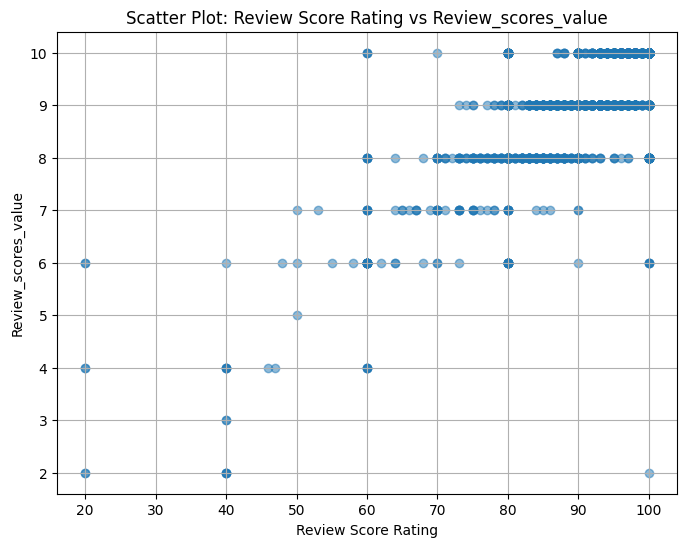

In [16]:
# Ambil data rating dan price
df_scatter = duckdb.sql("""
    SELECT review_scores_rating, review_scores_value
    FROM listing
    WHERE review_scores_value IS NOT NULL 
      AND review_scores_rating IS NOT NULL
""").df()

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df_scatter["review_scores_rating"], df_scatter["review_scores_value"], alpha=0.5)
plt.xlabel("Review Score Rating")
plt.ylabel("Review_scores_value")
plt.title("Scatter Plot: Review Score Rating vs Review_scores_value")
plt.grid(True)
plt.show()